## Остапенко Родіон КС32 
### Практичне завдання 2. Персептрон. Правило Відроу-Хоффа.
#### Варіант 20
#### $n=120$

#### Мета роботи: ознайомитися з поняттям персептрону як найпростішої нейронної мережі та правилом Відроу-Хоффа для його навчання; реалізувати програмно правило Відроу-Хоффа для персептрону, який розв’язує задачу класифікації.


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [17]:
# Згенерувати навчальний набір з n точок
X, y = make_blobs(n_samples=120, random_state=42, centers=2, cluster_std=1)
y = np.where(y == 0, -1, 1)
X.shape, y.shape

((120, 2), (120,))

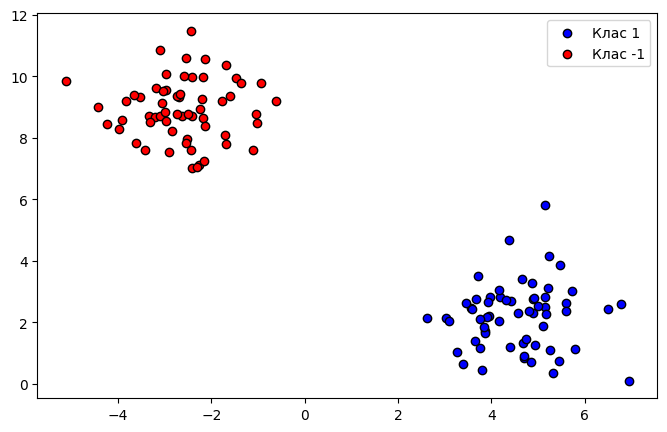

In [6]:
# Візуалізувати отримані класи
plt.figure(figsize=(8, 5))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Клас 1', edgecolor='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Клас -1', edgecolor='k')
plt.legend()
plt.show()

In [7]:
# Розбити згенерований набір на навчальну і тестову вибірки (85% і 15% відповідно)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train.shape, X_test.shape

((102, 2), (18, 2))

In [23]:
# Побудувати найпростішу нейронну мережу. Початкові вагові коефіцієнти задати випадково з інтервалу. Реалізувати правило Відроу-Хоффа для навчання персептрону.
class WidrowHoffPerceptron:
    def __init__(self, n_features, learning_rate=0.01, epochs=200):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = np.random.uniform(-0.5, 0.5, n_features + 1)
        
    # лінійні вхідні дані
    def net_input(self, X):
        return np.dot(X, self.weights[1:]) + self.weights[0]
    
    # Функція активації
    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)
    
    def fit(self, X, y):
            self.errors_ = []
            m = X.shape[0]
            
            for epoch in range(self.epochs):
                output = self.net_input(X)
                errors = (y - output)
                
                self.weights[1:] += self.learning_rate * X.T.dot(errors) / m
                self.weights[0] += self.learning_rate * errors.sum() / m
                
                # Зберігаємо MSE
                cost = (errors**2).sum() / (2.0 * m)
                self.errors_.append(cost)
            

In [33]:
# Навчити нейронну мережу на навчальному наборі. 
model = WidrowHoffPerceptron(n_features=X.shape[1], learning_rate=0.01, epochs=300)
model.fit(X_train, y_train)
for i in range(0, 300, 50):
    print(i, model.errors_[i])

0 0.16143639502904739
50 0.03554695589469998
100 0.03537564838375593
150 0.03521711835650368
200 0.035070409353372516
250 0.034934639922351025


In [37]:
# Протестувати на тестовому наборі.
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)

print(f"Точність на тестовій вибірці: {accuracy}")
print(f"Остання помилка: {model.errors_[-1]:.6f}")

Точність на тестовій вибірці: 1.0
Остання помилка: 0.034811
